# Predicción del Nivel de Desempeño en las Pruebas Saber 11

## Proyecto Final — Aprendizaje de Máquina (202610)
### Maestría en Inteligencia Artificial · Pontificia Universidad Javeriana

| Campo | Detalle |
|---|---|
| **Autores** | Carlos Manuel Carvajales Castrillo · Mateo Ruiz Mendoza |
| **Curso** | Aprendizaje de Máquina — 202610 |
| **Fecha** | Mayo 2026 |
| **Dataset** | Saber 11 — datos.gov.co (`kgxf-xxbe`) |

---

## 1. Introducción

### 1.1 Contexto del Problema

La prueba **Saber 11** es el examen de Estado colombiano que mide las competencias de los estudiantes al finalizar la educación media. Sus resultados constituyen uno de los criterios más importantes para el acceso a la educación superior y reflejan, en gran medida, la desigualdad estructural del sistema educativo del país.

Investigaciones en Educational Data Mining han demostrado que variables **socioeconómicas y de contexto** —como el estrato, el nivel educativo de los padres y el tipo de institución— tienen una influencia significativa sobre el rendimiento académico, incluso antes de conocer los puntajes individuales de las pruebas.

### 1.2 Objetivo General

> Construir un modelo de clasificación multiclase capaz de predecir el **nivel de desempeño global** de un estudiante en las pruebas Saber 11, utilizando exclusivamente variables sociodemográficas y de contexto educativo, **sin usar los puntajes de las pruebas**.

### 1.3 Objetivos Específicos

1. Obtener y validar un conjunto de datos representativo desde la API pública de datos.gov.co.
2. Realizar un análisis exploratorio exhaustivo de las variables disponibles.
3. Construir una variable objetivo (`nivel_desempeno`) a partir de `punt_global` con cinco categorías discretas.
4. Implementar y comparar al menos cuatro modelos de clasificación: Regresión Logística, Random Forest, Gradient Boosting y Red Neuronal MLP.
5. Evaluar los modelos con métricas de clasificación multiclase e interpretar los factores más relevantes.

### 1.4 Descripción del Dataset

El dataset **Saber 11** publicado en [datos.gov.co](https://www.datos.gov.co/resource/kgxf-xxbe) contiene registros de estudiantes que presentaron la prueba desde 2010 hasta 2022. Incluye información sobre:

- **Características demográficas del estudiante:** género, municipio y departamento de residencia.
- **Características de la institución educativa:** naturaleza (oficial/privada), jornada, calendario, área de ubicación, bilingüismo.
- **Características socioeconómicas del hogar:** estrato de vivienda, nivel educativo de los padres, acceso a internet y computador, número de personas y cuartos en el hogar.
- **Hábitos del estudiante:** horas de lectura diaria, horas de trabajo semanal, uso de internet.
- **Puntajes de las pruebas:** inglés, matemáticas, sociales y ciudadanas, ciencias naturales, lectura crítica y puntaje global (*estas columnas se excluyen como features*).

### 1.5 Motivación

La predicción del nivel de desempeño a partir de variables contextuales tiene implicaciones prácticas importantes: permite a instituciones educativas **identificar estudiantes en riesgo** antes del examen y diseñar intervenciones focalizadas. Además, evidenciar qué factores son más influyentes contribuye al debate sobre equidad educativa en Colombia.

---

## 2. Configuración del Entorno e Importaciones

Se importan todas las bibliotecas necesarias. Ejecutar la celda de instalación si es necesario en un entorno nuevo.

In [ ]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install pandas sodapy scikit-learn xgboost imbalanced-learn matplotlib seaborn pyarrow

In [1]:
# ─── Utilidades del sistema ──────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ─── Manipulación de datos ───────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── API de datos abiertos ───────────────────────────────────────────────────
from sodapy import Socrata

# ─── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.titlesize': 14
})
sns.set_style('whitegrid')
PALETTE = 'viridis'

# ─── Preprocesamiento ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ─── Modelos ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

# ─── Métricas ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

# ─── Reproducibilidad ────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Entorno configurado correctamente.')
print(f'   pandas  {pd.__version__} | numpy  {np.__version__}')

✅ Entorno configurado correctamente.
   pandas  2.3.2 | numpy  2.3.2


---
## 3. Obtención de Datos

### 3.1 Descripción de la Fuente

Los datos se obtienen mediante la **API Socrata** del portal de datos abiertos del gobierno colombiano ([datos.gov.co](https://www.datos.gov.co)). El dataset tiene el identificador `kgxf-xxbe` y es de acceso público, por lo que no requiere autenticación.

### 3.2 Estrategia de Descarga con Paginación

El dataset contiene millones de registros. Para obtener una muestra estadísticamente representativa sin sobrecargar la API, se implementa **paginación deslizante**:
- Se solicitan bloques de 10.000 registros.
- Se acumulan hasta alcanzar `MAX_RECORDS = 100.000`.
- Se añade un retardo de 0.5 segundos entre páginas para respetar los límites de la API.
- El resultado final se guarda en formato Parquet para evitar re-descargas en ejecuciones posteriores.

In [32]:
# ─── Librerías ────────────────────────────────────────────────────────────────
import os
import time
import pandas as pd
from sodapy import Socrata

# ─── Parámetros de descarga ───────────────────────────────────────────────────
DATASET_ID = 'kgxf-xxbe'
PAGE_SIZE  = 10_000
RAW_PATH   = 'saber11_20221_20224.parquet'

# Períodos a descargar
PERIODOS = ['20221', '20224']

# ─── Descarga con paginación por período ─────────────────────────────────────
if os.path.exists(RAW_PATH):

    print(f'📂 Cargando datos desde caché local: {RAW_PATH}')

    df_raw = pd.read_parquet(RAW_PATH)

else:

    print('🌐 Conectando a la API de datos.gov.co...')

    client = Socrata(
        'www.datos.gov.co',
        None,
        timeout=300
    )

    all_records = []

    # =========================================================================
    # Descarga individual por período
    # =========================================================================
    for periodo in PERIODOS:

        print(f'\n📥 Descargando período {periodo}...')

        offset = 0
        total_periodo = 0

        while True:

            try:

                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )

            except Exception as e:

                print(f'⚠️ Error en offset {offset}: {e}')
                print('🔄 Reintentando en 5 segundos...')

                time.sleep(5)

                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )

            # ================================================================
            # Fin de paginación
            # ================================================================
            if not batch:

                print(f'✅ Fin de descarga para período {periodo}')
                break

            # ================================================================
            # Acumulación
            # ================================================================
            all_records.extend(batch)

            batch_size = len(batch)

            total_periodo += batch_size
            offset += PAGE_SIZE

            print(
                f'   ✔ {periodo} | '
                f'Batch: {batch_size:,} registros | '
                f'Total período: {total_periodo:,}'
            )

            # ================================================================
            # Último batch
            # ================================================================
            if batch_size < PAGE_SIZE:

                print(f'✅ Último bloque recibido para {periodo}')
                break

            # ================================================================
            # Pausa anti-saturación API
            # ================================================================
            time.sleep(0.5)

    # =========================================================================
    # Conversión a DataFrame
    # =========================================================================
    df_raw = pd.DataFrame.from_records(all_records)

    # =========================================================================
    # Guardado local
    # =========================================================================
    df_raw.to_parquet(RAW_PATH, index=False)

    print(
        f'\n✅ Descarga completada: '
        f'{len(df_raw):,} registros guardados en "{RAW_PATH}"'
    )

# ─── Información final ────────────────────────────────────────────────────────
print(
    f'\n📊 Dimensiones del dataset: '
    f'{df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas'
)

# ─── Verificación de registros por período ───────────────────────────────────
print('\n📌 Registros por período:')

display(
    df_raw['periodo']
    .value_counts()
    .sort_index(ascending=False)
)

🌐 Conectando a la API de datos.gov.co...

📥 Descargando período 20221...
   ✔ 20221 | Batch: 10,000 registros | Total período: 10,000
   ✔ 20221 | Batch: 10,000 registros | Total período: 20,000
   ✔ 20221 | Batch: 49 registros | Total período: 20,049
✅ Último bloque recibido para 20221

📥 Descargando período 20224...
   ✔ 20224 | Batch: 10,000 registros | Total período: 10,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 20,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 30,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 40,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 50,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 60,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 70,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 80,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 90,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 100,000
   ✔ 20224 | Batch: 10,000 registros | Total período: 110,000
   ✔ 20

periodo
20224    1065888
20221      20049
Name: count, dtype: int64

In [33]:
# Contar registros por período
df_periodos = (
    df_raw
    .groupby('periodo')
    .size()
    .reset_index(name='cantidad_registros')
    .sort_values(by='periodo', ascending=False)
)

# Mostrar resultados
display(df_periodos)

,periodo,cantidad_registros
1,20224,1065888
0,20221,20049


In [35]:
# ─── Validación básica de calidad ─────────────────────────────────────────────
print('=' * 55)
print('VALIDACIÓN INICIAL DE CALIDAD')
print('=' * 55)

# Primeras filas
display(df_raw.head(3))

# Columnas disponibles
print(f'\nColumnas disponibles ({df_raw.shape[1]}):')
for col in sorted(df_raw.columns):
    print(f'  • {col}')

VALIDACIÓN INICIAL DE CALIDAD


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,...,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,cole_bilingue
0,20221,TI,AC202210004339,URBANO,B,ACADÉMICO,376520005862,376520005862,76,76520,...,Si,Si,B+,80,77,81,74,67,376,NaN
1,20221,TI,AC202210008120,RURAL,B,ACADÉMICO,376001000721,376001000721,76,76001,...,Si,Si,B1,74,100,76,74,66,393,N
2,20221,TI,AC202210022258,URBANO,B,TÉCNICO/ACADÉMICO,376001000543,376001000543,76,76001,...,Si,Si,B1,68,69,70,67,75,350,N



Columnas disponibles (51):
  • cole_area_ubicacion
  • cole_bilingue
  • cole_calendario
  • cole_caracter
  • cole_cod_dane_establecimiento
  • cole_cod_dane_sede
  • cole_cod_depto_ubicacion
  • cole_cod_mcpio_ubicacion
  • cole_codigo_icfes
  • cole_depto_ubicacion
  • cole_genero
  • cole_jornada
  • cole_mcpio_ubicacion
  • cole_naturaleza
  • cole_nombre_establecimiento
  • cole_nombre_sede
  • cole_sede_principal
  • desemp_ingles
  • estu_cod_depto_presentacion
  • estu_cod_mcpio_presentacion
  • estu_cod_reside_depto
  • estu_cod_reside_mcpio
  • estu_consecutivo
  • estu_depto_presentacion
  • estu_depto_reside
  • estu_estadoinvestigacion
  • estu_estudiante
  • estu_fechanacimiento
  • estu_genero
  • estu_mcpio_presentacion
  • estu_mcpio_reside
  • estu_nacionalidad
  • estu_pais_reside
  • estu_privado_libertad
  • estu_tipodocumento
  • fami_cuartoshogar
  • fami_educacionmadre
  • fami_educacionpadre
  • fami_estratovivienda
  • fami_personashogar
  • fami_tieneautomo

---
## 4. Análisis Exploratorio de Datos (EDA)

El EDA es la fase más crítica del pipeline. Aquí buscamos:
- Comprender la estructura y tipos de variables del dataset.
- Identificar valores nulos, duplicados y outliers.
- Explorar distribuciones de variables individuales y relaciones entre pares.
- Construir la variable objetivo y analizar el balance de clases.

### 4.1 Estructura General del Dataset

In [36]:
# ─── Copia de trabajo ────────────────────────────────────────────────────────
df = df_raw.copy()

# ─── Tipos de datos (conversión numérica para columnas de puntaje) ────────────
score_cols = [
    'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas',
    'punt_c_naturales', 'punt_lectura_critica', 'punt_global'
]

for col in score_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ─── Tipos de variables ───────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print(f'Variables numéricas  ({len(num_cols)}): {num_cols}')
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols[:10]} ...') # primeras 10

# ─── Resumen general ─────────────────────────────────────────────────────────
print('\n--- DataFrame Info ---')
df.info()

Variables numéricas  (6): ['punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_critica', 'punt_global']
Variables categóricas (45): ['periodo', 'estu_tipodocumento', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_cod_dane_establecimiento', 'cole_cod_dane_sede', 'cole_cod_depto_ubicacion', 'cole_cod_mcpio_ubicacion'] ...

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085937 entries, 0 to 1085936
Data columns (total 51 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   periodo                        1085937 non-null  object 
 1   estu_tipodocumento             1085937 non-null  object 
 2   estu_consecutivo               1085937 non-null  object 
 3   cole_area_ubicacion            1085935 non-null  object 
 4   cole_calendario                1085935 non-null  object 
 5   cole_caracter      

Columnas con valores nulos: 34


,Nulos,Porcentaje (%)
cole_bilingue,197035,18.14
fami_estratovivienda,72891,6.71
fami_tieneinternet,64279,5.92
fami_educacionmadre,62979,5.80
fami_educacionpadre,62762,5.78
fami_tieneautomovil,50021,4.61
fami_cuartoshogar,48259,4.44
fami_tienelavadora,48087,4.43
fami_tienecomputador,47940,4.41
fami_personashogar,46541,4.29


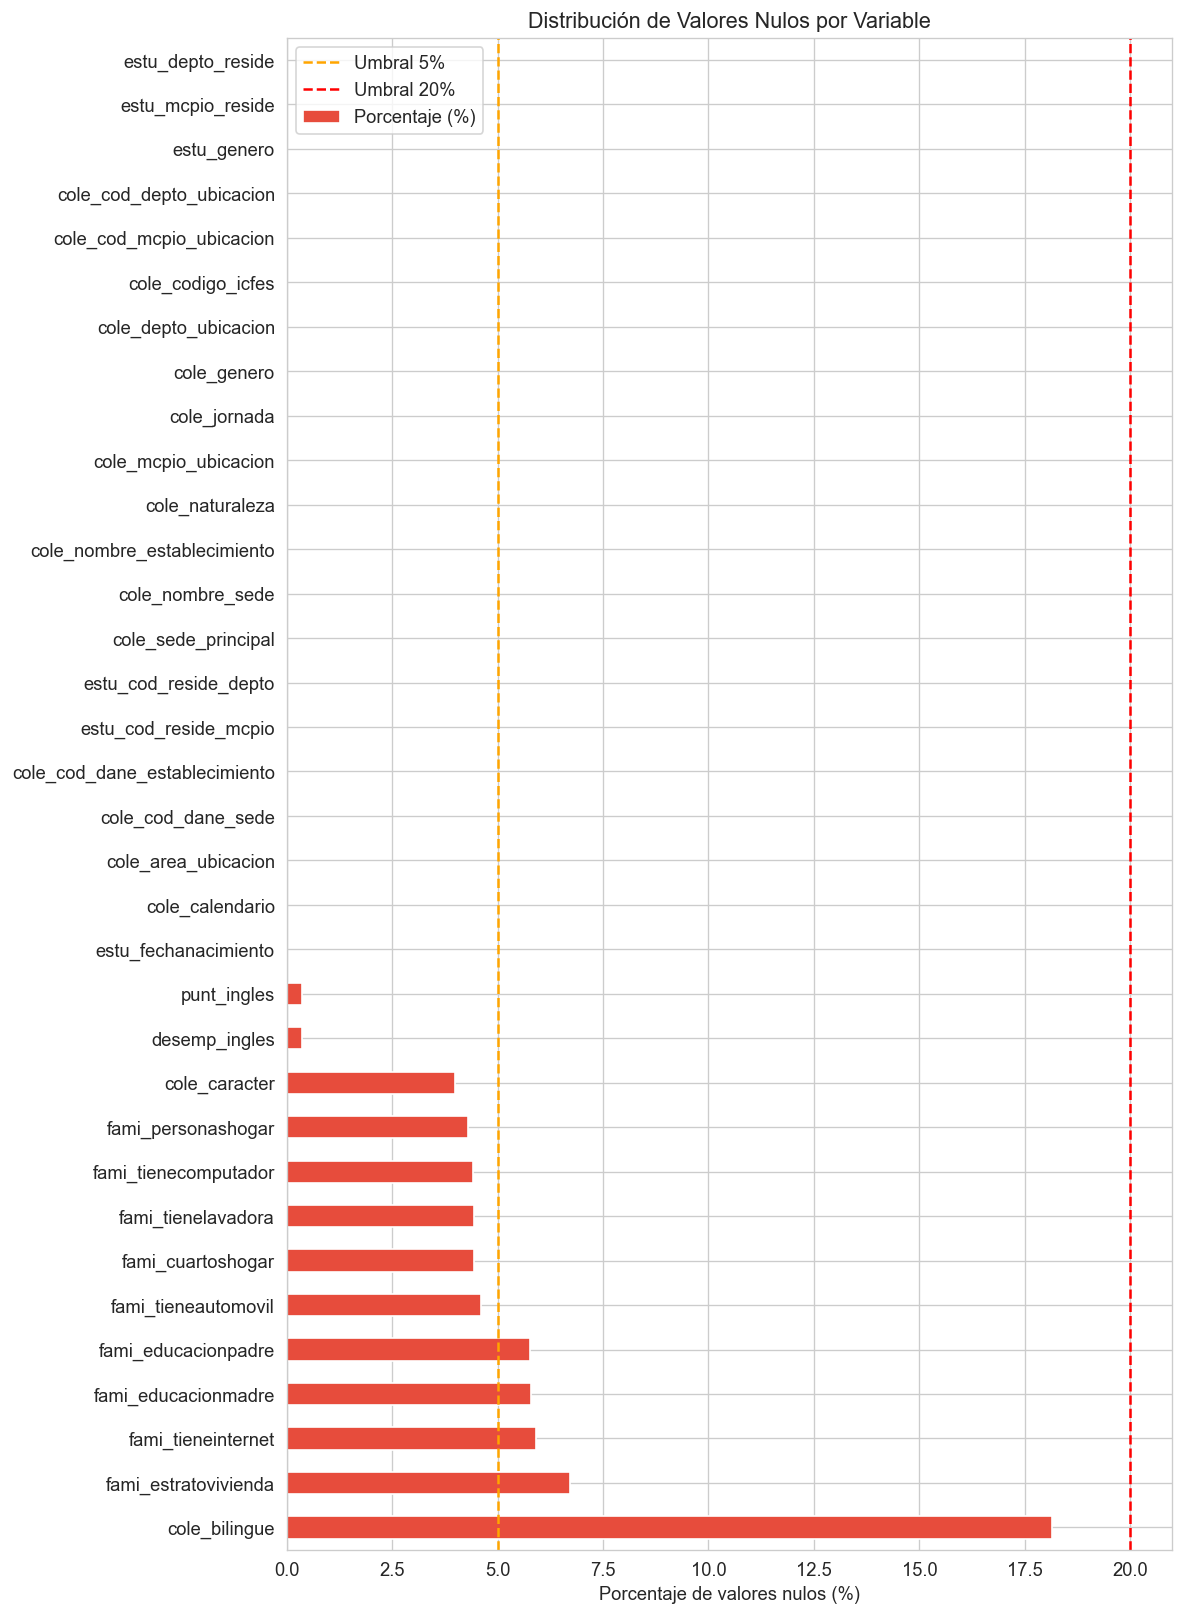


Registros duplicados: 533,096 (49.09%)


In [51]:
# ─── Análisis de valores nulos ────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Nulos': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

print(f'Columnas con valores nulos: {len(missing_df)}')
display(missing_df)

# Visualización de nulos
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    missing_df['Porcentaje (%)'].plot(kind='barh', ax=ax, color='#E74C3C', edgecolor='white')
    ax.set_xlabel('Porcentaje de valores nulos (%)')
    ax.set_title('Distribución de Valores Nulos por Variable')
    ax.axvline(5, color='orange', linestyle='--', label='Umbral 5%')
    ax.axvline(20, color='red', linestyle='--', label='Umbral 20%')
    ax.legend()
    plt.tight_layout()
    plt.show()

# ─── Duplicados ───────────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'\nRegistros duplicados: {n_dup:,} ({n_dup/len(df)*100:.2f}%)')

**Interpretación:** Las variables que superen el umbral del 20% de nulos serán candidatas a eliminación. Las que presenten entre 5% y 20% de nulos se imputarán con la moda (variables categóricas) o la mediana (variables numéricas). Porcentajes inferiores al 5% se tratan con imputación directa sin riesgo significativo para los modelos.

In [52]:
# ─── Estadísticos descriptivos — variables numéricas ─────────────────────────
print('Estadísticos descriptivos — Variables numéricas:')
display(df[num_cols].describe().T.round(2))

Estadísticos descriptivos — Variables numéricas:


,count,mean,std,min,25%,50%,75%,max
punt_ingles,1081879.0,50.11,13.33,0.0,39.0,49.0,58.0,100.0
punt_matematicas,1085937.0,50.71,12.30,0.0,42.0,51.0,59.0,100.0
punt_sociales_ciudadanas,1085937.0,47.83,12.00,0.0,38.0,47.0,57.0,100.0
punt_c_naturales,1085937.0,49.20,10.46,0.0,41.0,48.0,57.0,100.0
punt_lectura_critica,1085937.0,52.91,10.82,0.0,45.0,53.0,61.0,100.0
punt_global,1085937.0,250.78,52.25,0.0,210.0,247.0,288.0,477.0


### 4.2 Creación de la Variable Objetivo

Se discretiza `punt_global` (rango 0–500) en cinco categorías ordinales que corresponden a los niveles de desempeño definidos por el ICFES:

| Rango de Puntaje Global | Nivel de Desempeño |
|---|---|
| ≤ 200 | Muy Bajo |
| 201 – 250 | Bajo |
| 251 – 300 | Aceptable |
| 301 – 350 | Bueno |
| > 350 | Excelente |

**Importante:** Una vez creada la variable objetivo, **todas las columnas de puntaje** (`punt_*` y `desemp_ingles`) se eliminan del conjunto de features para evitar **data leakage**.

In [45]:
# ─── Creación de la variable objetivo ────────────────────────────────────────
# Eliminar registros sin puntaje global (no se puede construir el target)
df = df.dropna(subset=['punt_global']).copy()
print(f'Registros con puntaje global válido: {len(df):,}')

# Discretización
bins   = [0, 200, 250, 300, 350, 600]
labels = ['Muy Bajo', 'Bajo', 'Aceptable', 'Bueno', 'Excelente']

df['nivel_desempeno'] = pd.cut(
    df['punt_global'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

print('\nDistribución de la variable objetivo:')
dist = df['nivel_desempeno'].value_counts().reindex(labels)
dist_pct = (dist / dist.sum() * 100).round(2)
display(pd.DataFrame({'Conteo': dist, 'Porcentaje (%)': dist_pct}))

Registros con puntaje global válido: 1,085,937

Distribución de la variable objetivo:


,Conteo,Porcentaje (%)
nivel_desempeno,,
Muy Bajo,209682,19.31
Bajo,355506,32.74
Aceptable,316034,29.10
Bueno,169999,15.65
Excelente,34716,3.20


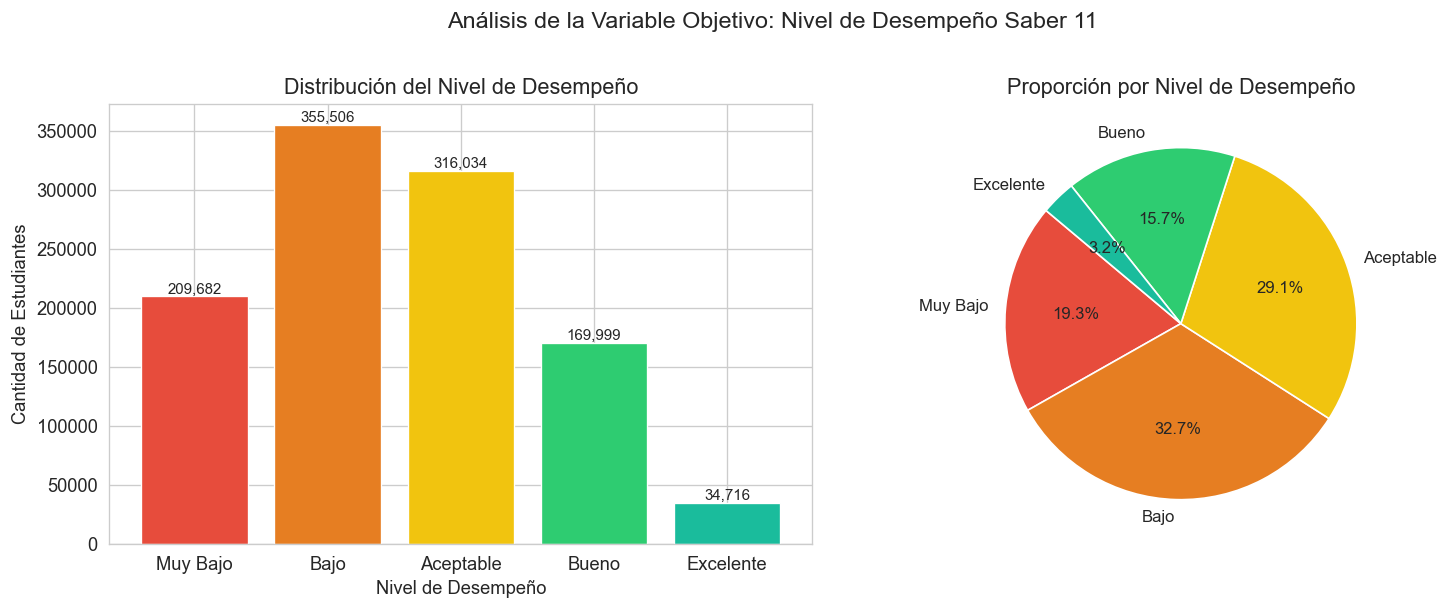

In [46]:
# ─── Visualización de la distribución del target ──────────────────────────────
ORDER = ['Muy Bajo', 'Bajo', 'Aceptable', 'Bueno', 'Excelente']
colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#1ABC9C']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot
ax = axes[0]
counts = df['nivel_desempeno'].value_counts().reindex(ORDER)
bars = ax.bar(ORDER, counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Distribución del Nivel de Desempeño')
ax.set_xlabel('Nivel de Desempeño')
ax.set_ylabel('Cantidad de Estudiantes')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
ax2 = axes[1]
ax2.pie(counts.values, labels=ORDER, colors=colors, autopct='%1.1f%%',
        startangle=140, textprops={'fontsize': 10})
ax2.set_title('Proporción por Nivel de Desempeño')

plt.suptitle('Análisis de la Variable Objetivo: Nivel de Desempeño Saber 11', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** La distribución del nivel de desempeño tiende a concentrarse en las categorías centrales (Bajo y Aceptable), lo que es consistente con estudios previos del ICFES. Esto genera un **desbalance de clases** que debe tenerse en cuenta durante el modelado: se utilizará `class_weight='balanced'` y la métrica **F1-macro** como principal criterio de comparación.

### 4.3 Análisis de Variables Categóricas Clave

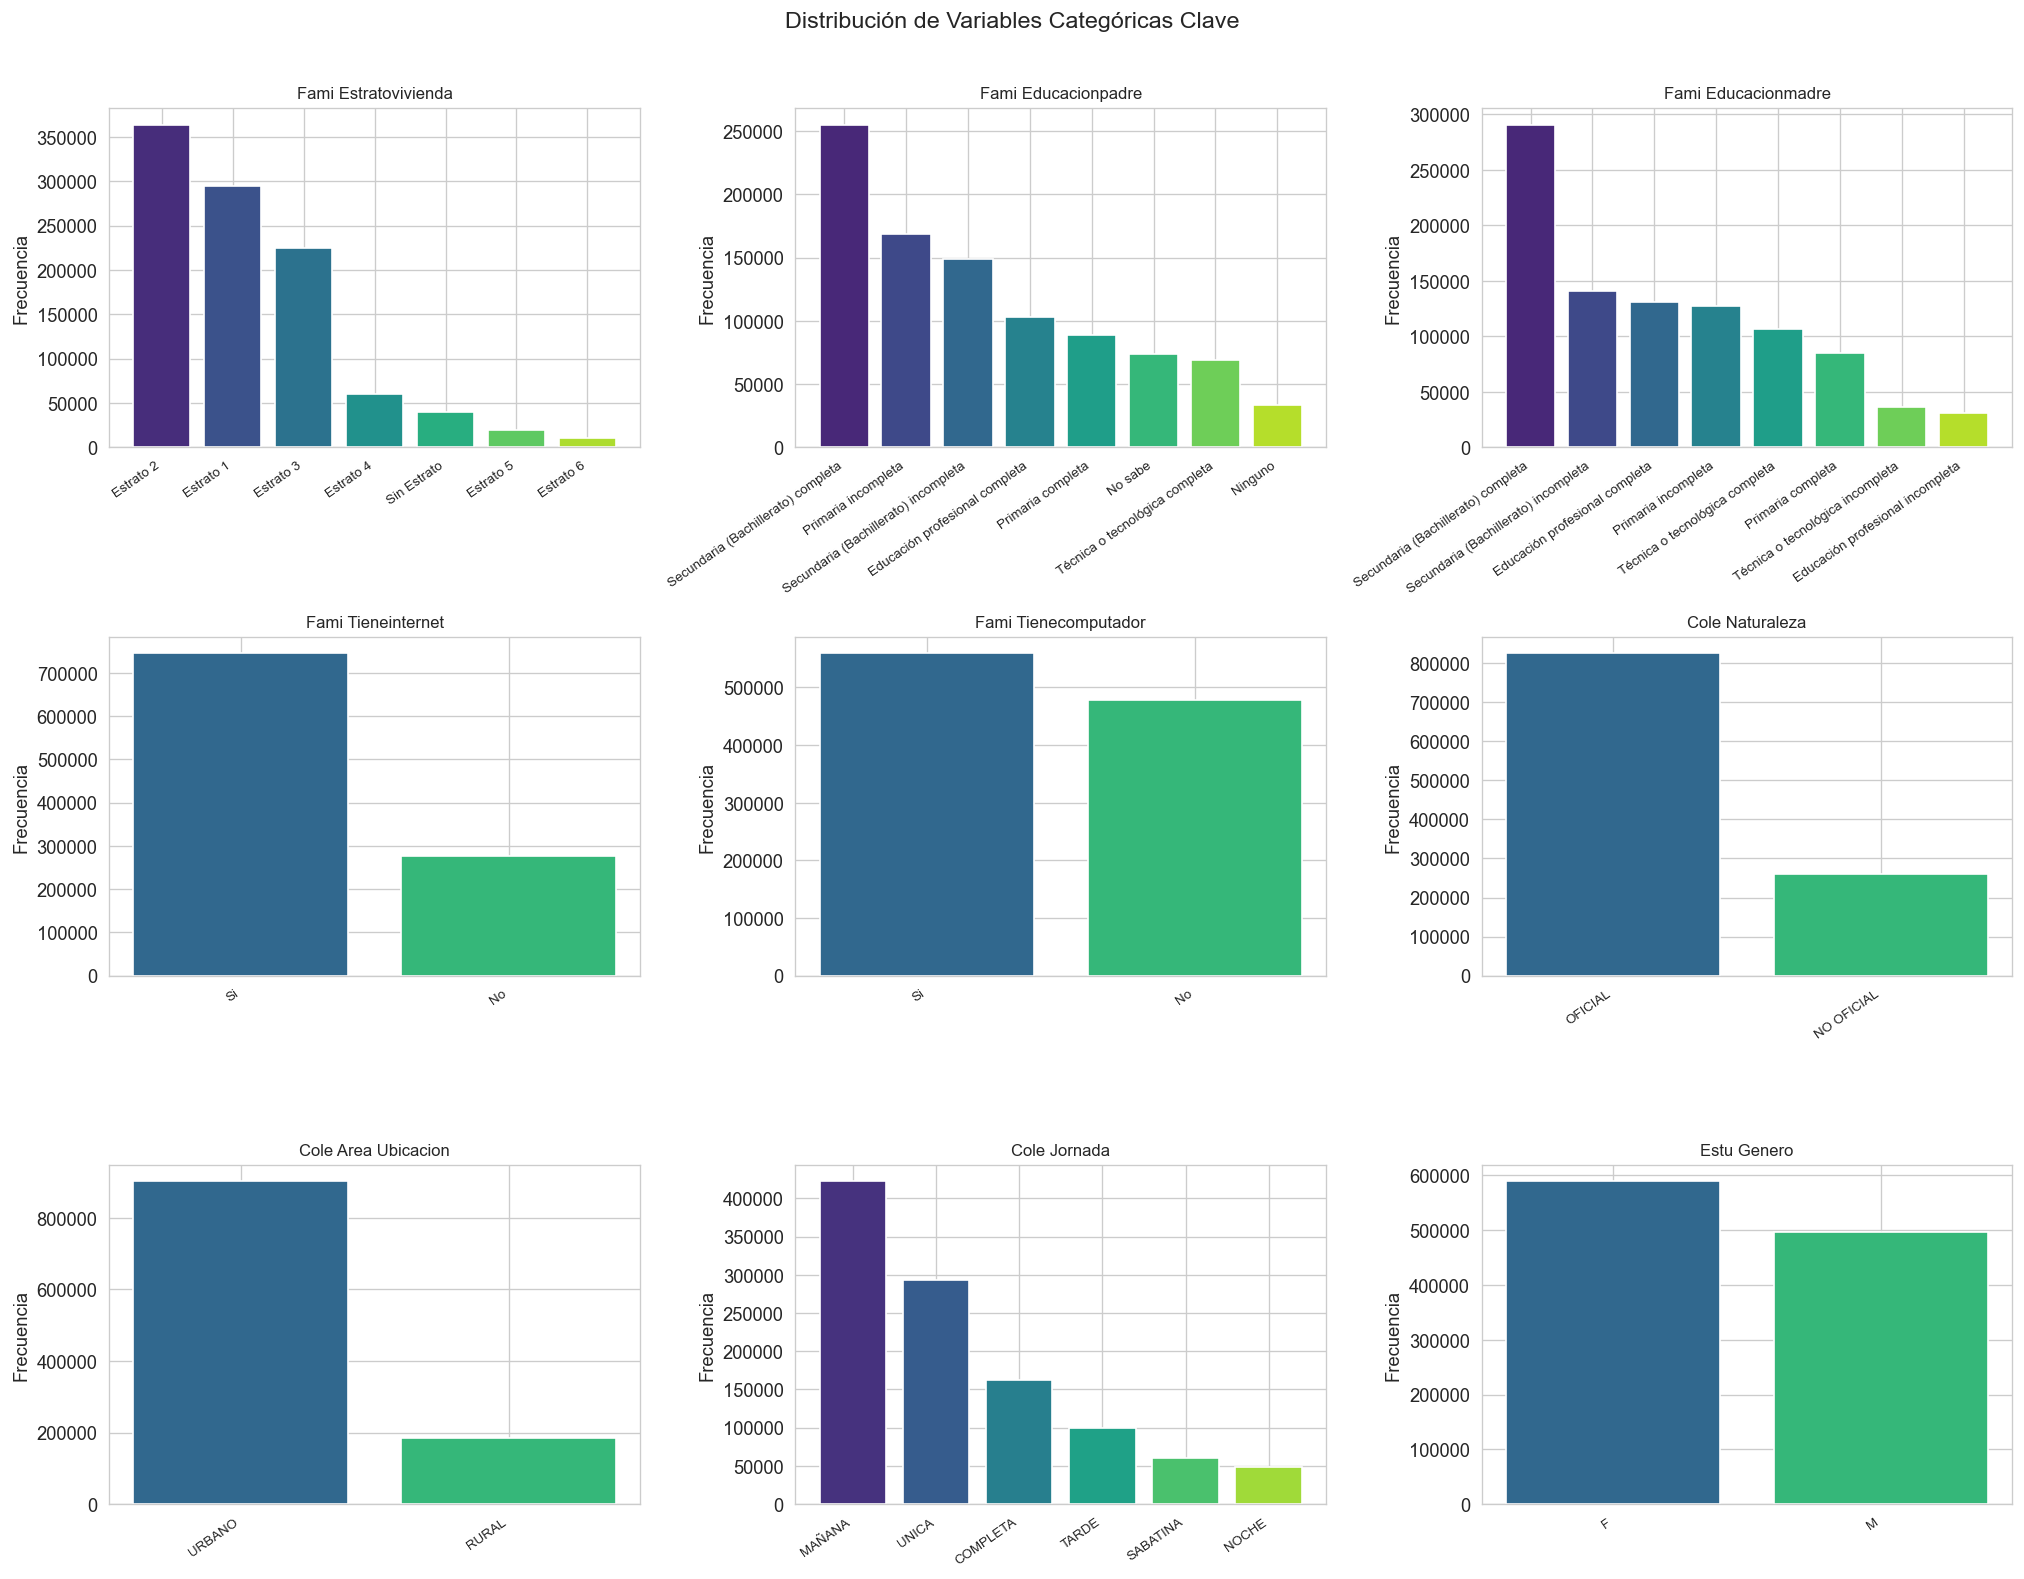

In [53]:
# ─── Variables categóricas de interés ────────────────────────────────────────
CAT_VARS_INTEREST = [
    'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre',
    'fami_tieneinternet', 'fami_tienecomputador',
    'cole_naturaleza', 'cole_area_ubicacion', 'cole_jornada',
    'estu_genero'
]

# Filtrar solo las que existen en el dataset
CAT_VARS_INTEREST = [c for c in CAT_VARS_INTEREST if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
axes = axes.flatten()

for i, col in enumerate(CAT_VARS_INTEREST):
    ax = axes[i]
    top_vals = df[col].value_counts().head(8)
    ax.bar(range(len(top_vals)), top_vals.values,
           color=sns.color_palette(PALETTE, len(top_vals)), edgecolor='white')
    ax.set_xticks(range(len(top_vals)))
    ax.set_xticklabels(top_vals.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Frecuencia')

# Ocultar ejes vacíos
for j in range(len(CAT_VARS_INTEREST), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Categóricas Clave', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:** La distribución del **estrato socioeconómico** muestra una concentración en estratos 1 y 2, lo que refleja la composición socioeconómica de los estudiantes colombianos que presentan Saber 11. La **naturaleza del colegio** (oficial vs. privada) y el **acceso a internet y computador** en el hogar son variables con alta heterogeneidad, lo que las convierte en candidatos fuertes como predictores del nivel de desempeño.

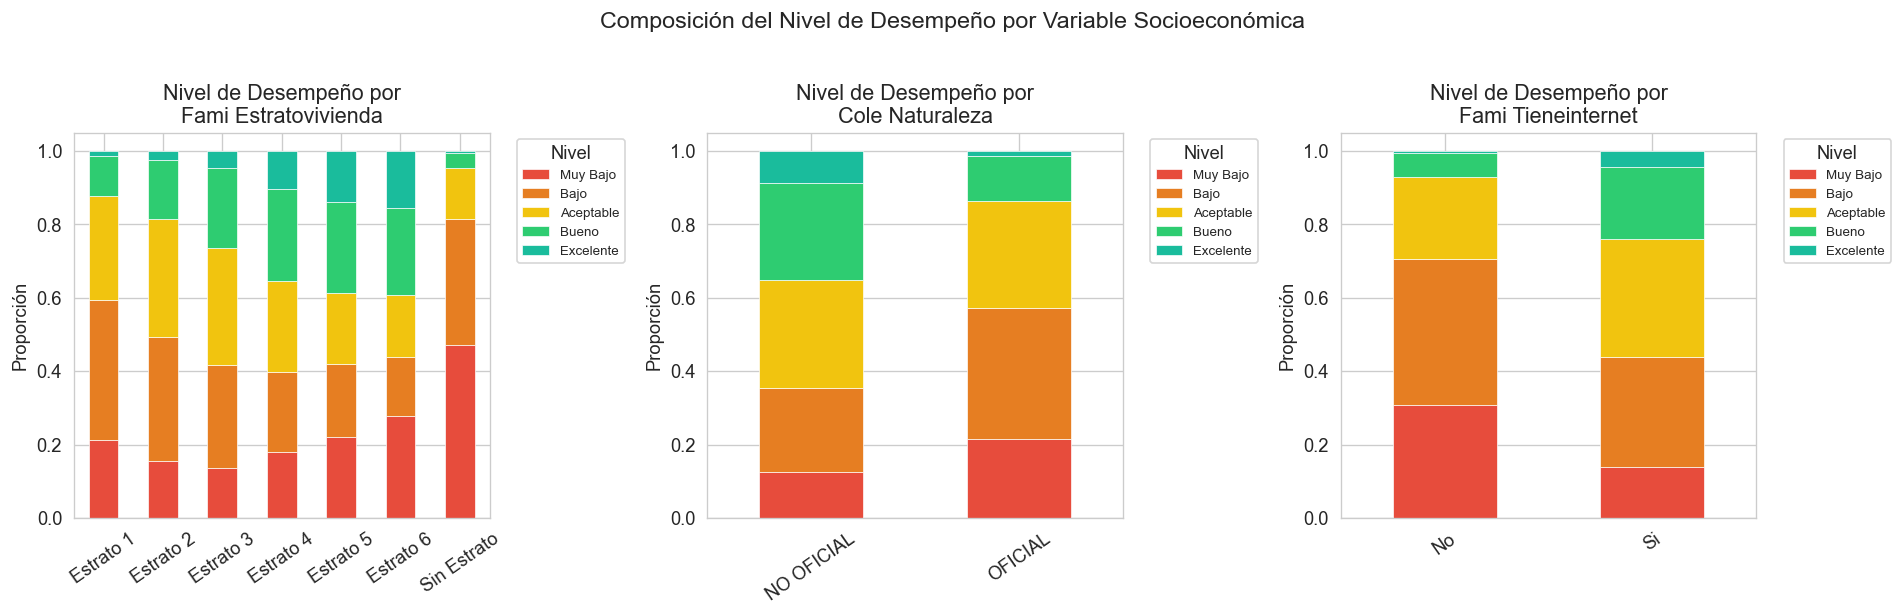

In [54]:
# ─── Nivel de desempeño vs. variables categóricas clave ──────────────────────
CROSS_VARS = ['fami_estratovivienda', 'cole_naturaleza', 'fami_tieneinternet']
CROSS_VARS = [c for c in CROSS_VARS if c in df.columns]

fig, axes = plt.subplots(1, len(CROSS_VARS), figsize=(16, 5))
if len(CROSS_VARS) == 1:
    axes = [axes]

for ax, col in zip(axes, CROSS_VARS):
    ct = pd.crosstab(df[col], df['nivel_desempeno'], normalize='index')[ORDER]
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#1ABC9C'],
            edgecolor='white', linewidth=0.4)
    ax.set_title(f'Nivel de Desempeño por\n{col.replace("_"," ").title()}')
    ax.set_xlabel('')
    ax.set_ylabel('Proporción')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Nivel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('Composición del Nivel de Desempeño por Variable Socioeconómica', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Se observa una relación clara entre el estrato socioeconómico y el nivel de desempeño: los estudiantes de estratos altos tienen mayor proporción en categorías Bueno y Excelente. Los estudiantes de colegios privados también tienden a concentrarse en niveles superiores. El acceso a internet presenta un patrón similar, lo que sugiere que la conectividad actúa como proxy de condiciones socioeconómicas favorables.

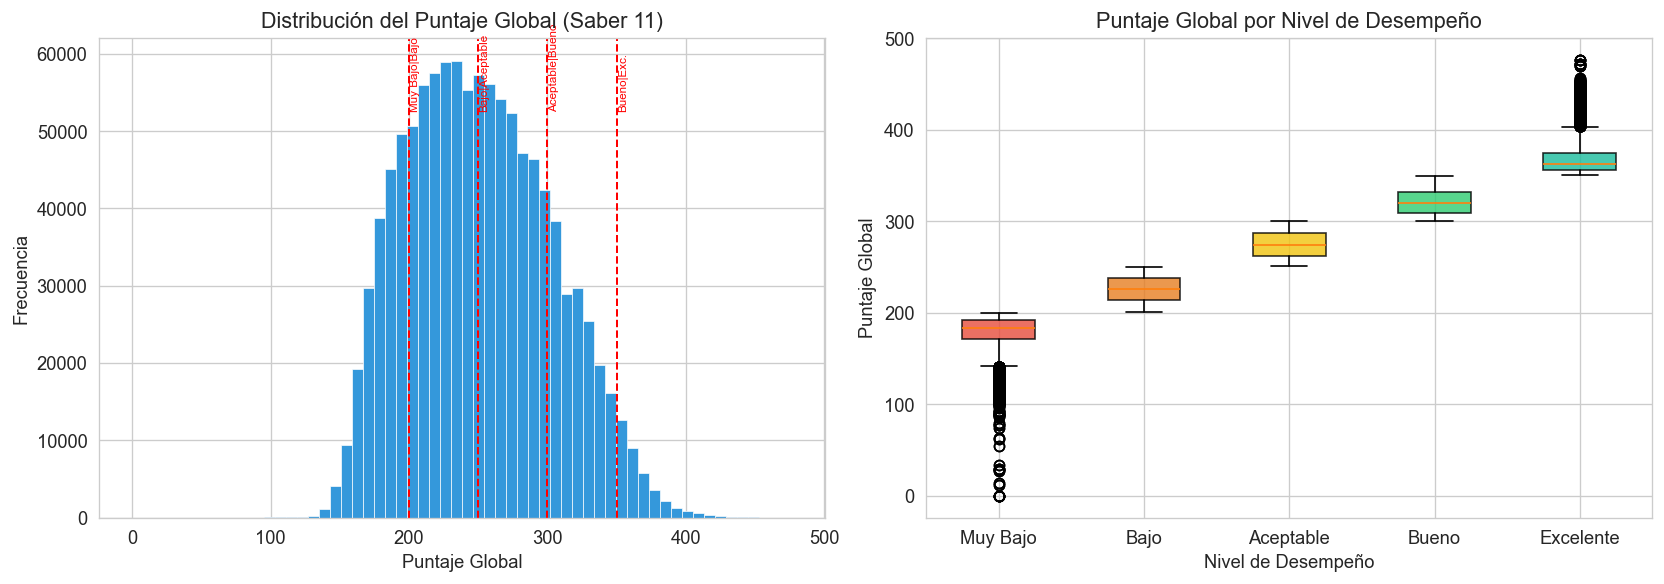

In [55]:
# ─── Distribución de puntaje global por nivel ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del puntaje global
ax = axes[0]
ax.hist(df['punt_global'].dropna(), bins=60, color='#3498DB', edgecolor='white', linewidth=0.4)
for xline, label in zip([200, 250, 300, 350], ['Muy Bajo|Bajo','Bajo|Aceptable','Aceptable|Bueno','Bueno|Exc.']):
    ax.axvline(xline, color='red', linestyle='--', linewidth=1.2)
    ax.text(xline+1, ax.get_ylim()[1]*0.85, label, rotation=90, fontsize=7, color='red')
ax.set_title('Distribución del Puntaje Global (Saber 11)')
ax.set_xlabel('Puntaje Global')
ax.set_ylabel('Frecuencia')

# Boxplot por nivel
ax2 = axes[1]
data_plot = [df[df['nivel_desempeno'] == lvl]['punt_global'].dropna() for lvl in ORDER]
bp = ax2.boxplot(data_plot, labels=ORDER, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], ['#E74C3C','#E67E22','#F1C40F','#2ECC71','#1ABC9C']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_title('Puntaje Global por Nivel de Desempeño')
ax2.set_xlabel('Nivel de Desempeño')
ax2.set_ylabel('Puntaje Global')

plt.tight_layout()
plt.show()

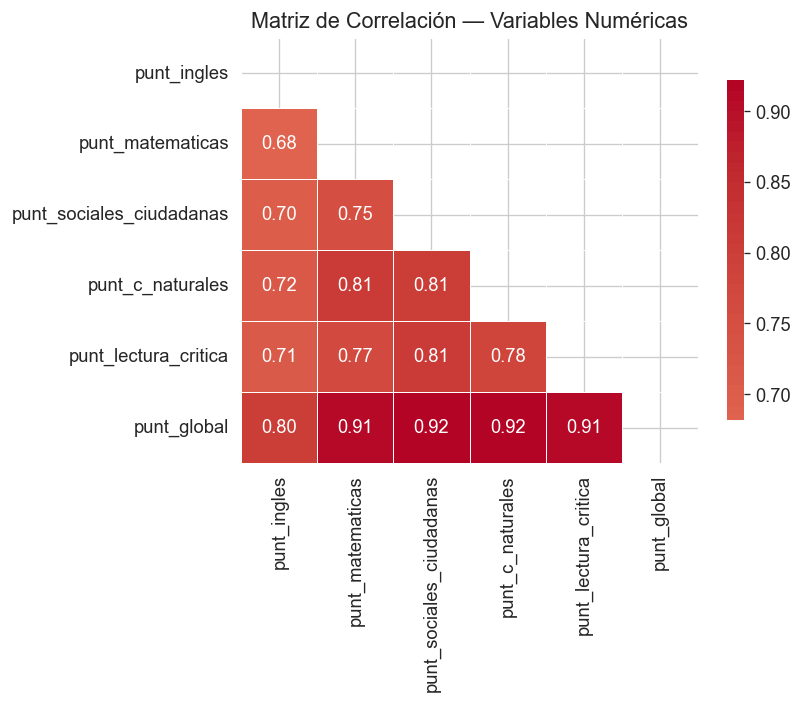

In [50]:
# ─── Matriz de correlación — variables numéricas ──────────────────────────────
num_for_corr = [c for c in num_cols if c in df.columns]

if len(num_for_corr) >= 2:
    corr_matrix = df[num_for_corr].corr()

    fig, ax = plt.subplots(figsize=(max(7, len(num_for_corr)), max(6, len(num_for_corr))))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, linewidths=0.5,
        ax=ax, cbar_kws={'shrink': 0.8}
    )
    ax.set_title('Matriz de Correlación — Variables Numéricas')
    plt.tight_layout()
    plt.show()
else:
    print('No hay suficientes variables numéricas para la matriz de correlación.')

### 4.4 Síntesis del EDA

| Hallazgo | Implicación para el modelado |
|---|---|
| Desbalance de clases en la variable objetivo | Usar `class_weight='balanced'` y F1-macro |
| Variables con alta nulidad (>20%) | Eliminar o imputar con cautela |
| Relación clara entre estrato y desempeño | `fami_estratovivienda` será feature relevante |
| Acceso a tecnología como proxy socioeconómico | Incluir `fami_tieneinternet`, `fami_tienecomputador` |
| Tipo de institución diferencia el desempeño | `cole_naturaleza` es feature informativa |

---

## 5. Preprocesamiento de Datos

El preprocesamiento sigue un pipeline claro y justificado:

1. **Eliminación de columnas de puntaje** → Prevenir data leakage.
2. **Eliminación de columnas de alta cardinalidad** → Columnas con demasiados valores únicos (IDs, nombres de colegio) aportan ruido.
3. **Manejo de nulos** → Imputación con moda para categóricas y mediana para numéricas.
4. **Codificación** → Ordinal Encoding para variables con orden natural, One-Hot para nominales de baja cardinalidad.
5. **Escalamiento** → StandardScaler para variables numéricas (requerido por Logistic Regression y MLP).
6. **División train/test** → Estratificada para preservar proporciones de clase.

### 5.1 Selección de Features

In [56]:
# ─── Columnas a excluir (data leakage + identificadores) ─────────────────────
SCORE_COLS = [
    'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas',
    'punt_c_naturales', 'punt_lectura_critica', 'punt_global', 'desemp_ingles'
]

ID_COLS = [
    'estu_consecutivo', 'cole_cod_dane_establecimiento',
    'cole_nombre_establecimiento', 'cole_cod_mcpio_ubicacion',
    'estu_fechanacimiento'
]

EXCLUDE = SCORE_COLS + ID_COLS
EXCLUDE = [c for c in EXCLUDE if c in df.columns]

# ─── Features seleccionadas ──────────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE + ['nivel_desempeno']]

# Eliminar columnas de alta cardinalidad (>50 valores únicos en variable tipo object)
HIGH_CARD = [
    c for c in FEATURE_COLS
    if df[c].dtype == 'object' and df[c].nunique() > 50
]
print(f'Columnas de alta cardinalidad eliminadas: {HIGH_CARD}')
FEATURE_COLS = [c for c in FEATURE_COLS if c not in HIGH_CARD]

print(f'\n✅ Total de features seleccionadas: {len(FEATURE_COLS)}')
print('Features:', FEATURE_COLS)

Columnas de alta cardinalidad eliminadas: ['cole_cod_dane_sede', 'cole_codigo_icfes', 'cole_mcpio_ubicacion', 'cole_nombre_sede', 'estu_cod_mcpio_presentacion', 'estu_cod_reside_mcpio', 'estu_mcpio_presentacion', 'estu_mcpio_reside']

✅ Total de features seleccionadas: 31
Features: ['periodo', 'estu_tipodocumento', 'cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_cod_depto_ubicacion', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'estu_cod_depto_presentacion', 'estu_cod_reside_depto', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_genero', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cole_bilingue']


In [57]:
# ─── Construcción del dataset de modelado ────────────────────────────────────
df_model = df[FEATURE_COLS + ['nivel_desempeno']].copy()

# Eliminar filas donde el target es nulo
df_model = df_model.dropna(subset=['nivel_desempeno'])

X = df_model[FEATURE_COLS].copy()
y = df_model['nivel_desempeno'].astype(str)  # convertir a string para sklearn

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nClases: {sorted(y.unique())}')

# ─── Identificar tipos de columnas ───────────────────────────────────────────
NUM_FEATURES = X.select_dtypes(include='number').columns.tolist()
CAT_FEATURES = X.select_dtypes(exclude='number').columns.tolist()

print(f'\nFeatures numéricas ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'Features categóricas ({len(CAT_FEATURES)}): {CAT_FEATURES}')

X shape: (1085937, 31)
y shape: (1085937,)

Clases: ['Aceptable', 'Bajo', 'Bueno', 'Excelente', 'Muy Bajo']

Features numéricas (0): []
Features categóricas (31): ['periodo', 'estu_tipodocumento', 'cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_cod_depto_ubicacion', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'estu_cod_depto_presentacion', 'estu_cod_reside_depto', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_genero', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cole_bilingue']


In [58]:
# ─── Pipeline de preprocesamiento ─────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,    NUM_FEATURES),
    ('cat', categorical_pipeline, CAT_FEATURES)
], remainder='drop')

print('✅ Pipeline de preprocesamiento construido.')
print('   - Numéricas: imputación mediana + StandardScaler')
print('   - Categóricas: imputación moda + OrdinalEncoder')

✅ Pipeline de preprocesamiento construido.
   - Numéricas: imputación mediana + StandardScaler
   - Categóricas: imputación moda + OrdinalEncoder


In [59]:
# ─── División train/test estratificada ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Tamaño del conjunto de prueba:        {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)')

# Verificar proporción de clases en train vs test
print('\nProporción de clases en train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporción de clases en test:')
print(y_test.value_counts(normalize=True).round(3))

Tamaño del conjunto de entrenamiento: 868,749 registros (80.0%)
Tamaño del conjunto de prueba:        217,188 registros (20.0%)

Proporción de clases en train:
nivel_desempeno
Bajo         0.327
Aceptable    0.291
Muy Bajo     0.193
Bueno        0.157
Excelente    0.032
Name: proportion, dtype: float64

Proporción de clases en test:
nivel_desempeno
Bajo         0.327
Aceptable    0.291
Muy Bajo     0.193
Bueno        0.157
Excelente    0.032
Name: proportion, dtype: float64


---
## 6. Modelado

Se implementan cuatro modelos de clasificación multiclase con justificación de su selección:

| Modelo | Justificación |
|---|---|
| **Regresión Logística** | Baseline interpretable; eficiente con features escaladas |
| **Random Forest** | Robusto a valores atípicos; captura relaciones no lineales; importancia de features |
| **Gradient Boosting** | Alto desempeño predictivo; maneja desbalance bien con `subsample` |
| **MLP (Red Neuronal)** | Captura relaciones complejas y no lineales entre features |

Cada modelo se envuelve en un **Pipeline completo** que incluye el preprocesamiento, garantizando que no haya fuga de información entre train y test.

La métrica principal de comparación es el **F1-score macro** (considera todas las clases equitativamente, apropiado para desbalance).

### 6.1 Funciones de Utilidad

In [60]:
# ─── Función de evaluación estándar ───────────────────────────────────────────
CLASSES = ['Muy Bajo', 'Bajo', 'Aceptable', 'Bueno', 'Excelente']

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """
    Entrena el modelo, realiza CV en train y devuelve métricas en test.
    Retorna un dict con todas las métricas.
    """

    # CV en entrenamiento
    cv_scores = cross_val_score(
        model,
        X_tr,
        y_tr,
        cv=StratifiedKFold(
            n_splits=cv,
            shuffle=True,
            random_state=RANDOM_STATE
        ),
        scoring='f1_macro',
        n_jobs=-1
    )

    # Entrenamiento final
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Métricas
    acc     = accuracy_score(y_te, y_pred)
    f1_mac  = f1_score(y_te, y_pred, average='macro', zero_division=0)
    f1_wei  = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    prec    = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec     = recall_score(y_te, y_pred, average='macro', zero_division=0)

    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")

    print(f"  CV F1-macro (train): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Accuracy (test):     {acc:.4f}")
    print(f"  F1-macro (test):     {f1_mac:.4f}")
    print(f"  F1-weighted (test):  {f1_wei:.4f}")
    print(f"  Precision-macro:     {prec:.4f}")
    print(f"  Recall-macro:        {rec:.4f}")

    print()
    print(
        classification_report(
            y_te,
            y_pred,
            target_names=CLASSES,
            zero_division=0
        )
    )

    return {
        'Modelo': name,
        'CV F1-macro': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'Accuracy': round(acc, 4),
        'F1-macro': round(f1_mac, 4),
        'F1-weighted': round(f1_wei, 4),
        'Precision-macro': round(prec, 4),
        'Recall-macro': round(rec, 4),
        'model_obj': model,
        'y_pred': y_pred
    }

results_list = []

print('✅ Funciones de evaluación definidas.')

✅ Funciones de evaluación definidas.


### 6.2 Modelo 1: Regresión Logística (Baseline)

La regresión logística multiclase (`multi_class='multinomial'`) sirve como **línea base interpretable**. Su desempeño fija el umbral mínimo esperado para los modelos más complejos.

In [61]:
# ─── Regresión Logística ───────────────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        multi_class='multinomial',
        solver='lbfgs',
        C=1.0
    ))
])

res_lr = evaluate_model('Regresión Logística', lr_pipeline, X_train, y_train, X_test, y_test)
results_list.append({k: v for k, v in res_lr.items() if k not in ['model_obj', 'y_pred']})


  Regresión Logística
  CV F1-macro (train): nan ± nan
  Accuracy (test):     0.3075
  F1-macro (test):     0.2903
  F1-weighted (test):  0.3088
  Precision-macro:     0.2930
  Recall-macro:        0.3718

              precision    recall  f1-score   support

    Muy Bajo       0.35      0.25      0.29     63207
        Bajo       0.40      0.24      0.30     71101
   Aceptable       0.22      0.22      0.22     34000
       Bueno       0.12      0.62      0.20      6943
   Excelente       0.37      0.52      0.43     41937

    accuracy                           0.31    217188
   macro avg       0.29      0.37      0.29    217188
weighted avg       0.34      0.31      0.31    217188



### 6.3 Modelo 2: Random Forest

El **Random Forest** es un ensemble de árboles de decisión entrenados con bootstrap. Es robusto a outliers, maneja variables categóricas ordinales bien y permite extraer importancia de features de forma nativa. Se usa `class_weight='balanced_subsample'` para manejar el desbalance.

In [20]:
# ─── Random Forest con búsqueda de hiperparámetros ────────────────────────────
rf_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

res_rf = evaluate_model('Random Forest', rf_base, X_train, y_train, X_test, y_test)
results_list.append({k: v for k, v in res_rf.items() if k not in ['model_obj', 'y_pred']})


  Random Forest
  CV F1-macro (train): 0.4264 ± 0.0038
  Accuracy (test):     0.4454
  F1-macro (test):     0.4382
  F1-weighted (test):  0.4451
  Precision-macro:     0.4170
  Recall-macro:        0.4915

              precision    recall  f1-score   support

    Muy Bajo       0.47      0.41      0.44      3575
        Bajo       0.52      0.40      0.45      4074
   Aceptable       0.36      0.44      0.39      1584
       Bueno       0.30      0.60      0.40       387
   Excelente       0.43      0.61      0.51      1744

    accuracy                           0.45     11364
   macro avg       0.42      0.49      0.44     11364
weighted avg       0.46      0.45      0.45     11364



### 6.4 Modelo 3: Gradient Boosting

El **Gradient Boosting** entrena árboles de forma secuencial, donde cada árbol corrige los errores del anterior. Es uno de los algoritmos con mayor poder predictivo para datos tabulares. Se usa `HistGradientBoostingClassifier` de sklearn, que maneja nulos nativamente y es más eficiente para datasets grandes.

In [21]:
# ─── Gradient Boosting (HistGradientBoosting — eficiente para datos grandes) ──
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoosting no requiere preprocesamiento de escalamiento,
# pero sí necesita features numéricas. Usamos solo imputación.
preprocessor_hgb = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'),     NUM_FEATURES),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), CAT_FEATURES)
], remainder='drop')

hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_hgb),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

res_hgb = evaluate_model('Gradient Boosting (HGB)', hgb_pipeline, X_train, y_train, X_test, y_test)
results_list.append({k: v for k, v in res_hgb.items() if k not in ['model_obj', 'y_pred']})


  Gradient Boosting (HGB)
  CV F1-macro (train): 0.3690 ± 0.0079
  Accuracy (test):     0.3860
  F1-macro (test):     0.3755
  F1-weighted (test):  0.3838
  Precision-macro:     0.3623
  Recall-macro:        0.4521

              precision    recall  f1-score   support

    Muy Bajo       0.44      0.31      0.36      3575
        Bajo       0.49      0.32      0.38      4074
   Aceptable       0.29      0.40      0.34      1584
       Bueno       0.21      0.59      0.31       387
   Excelente       0.39      0.64      0.48      1744

    accuracy                           0.39     11364
   macro avg       0.36      0.45      0.38     11364
weighted avg       0.42      0.39      0.38     11364



### 6.5 Modelo 4: Red Neuronal MLP

El **Perceptrón Multicapa (MLP)** puede capturar relaciones altamente no lineales entre features. Se usa una arquitectura de dos capas ocultas `(256, 128)` con activación ReLU y regularización L2 (`alpha`). Las features deben estar escaladas (ya incluido en el pipeline).

In [22]:
# ─── Red Neuronal MLP ─────────────────────────────────────────────────────────
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        alpha=0.001,           # regularización L2
        batch_size=512,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

res_mlp = evaluate_model('MLP Neural Network', mlp_pipeline, X_train, y_train, X_test, y_test)
results_list.append({k: v for k, v in res_mlp.items() if k not in ['model_obj', 'y_pred']})

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PERSONAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Users\PERSONAL\AppData\L

---
## 7. Evaluación y Comparación de Modelos

### 7.1 Tabla Comparativa de Métricas

In [23]:
# ─── Tabla comparativa ────────────────────────────────────────────────────────
df_results = pd.DataFrame(results_list)
df_results = df_results.set_index('Modelo')

# Resaltar mejor valor por columna
display(
    df_results.style
    .highlight_max(axis=0, color='#d4edda', subset=['CV F1-macro','Accuracy','F1-macro','F1-weighted'])
    .highlight_min(axis=0, color='#f8d7da', subset=['CV F1-macro','Accuracy','F1-macro','F1-weighted'])
    .format('{:.4f}')
    .set_caption('Comparación de Modelos — Métricas en Conjunto de Prueba')
)

best_model_name = df_results['F1-macro'].idxmax()
print(f'\n🏆 Mejor modelo por F1-macro: {best_model_name}')

,CV F1-macro,CV Std,Accuracy,F1-macro,F1-weighted,Precision-macro,Recall-macro
Modelo,,,,,,,
Regresión Logística,0.3072,0.0029,0.3260,0.3112,0.3288,0.3123,0.3993
Random Forest,0.4264,0.0038,0.4454,0.4382,0.4451,0.4170,0.4915
Gradient Boosting (HGB),0.3690,0.0079,0.3860,0.3755,0.3838,0.3623,0.4521



🏆 Mejor modelo por F1-macro: Random Forest


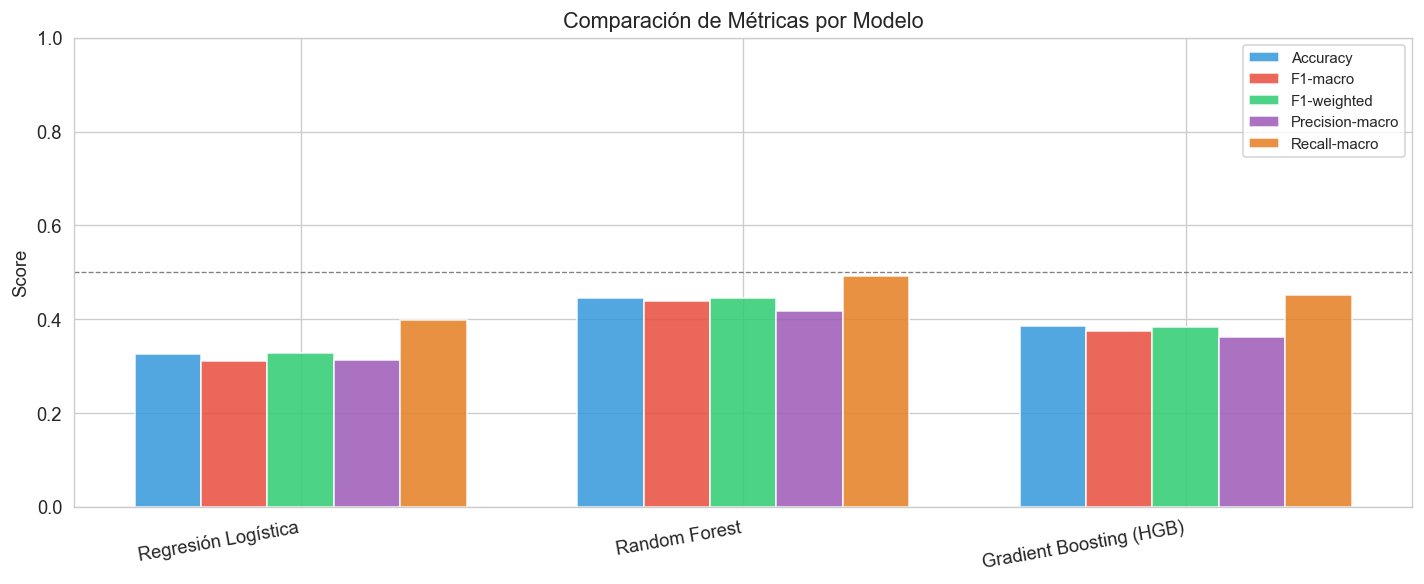

In [24]:
# ─── Gráfico comparativo de métricas ──────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'F1-macro', 'F1-weighted', 'Precision-macro', 'Recall-macro']
df_plot = df_results[metrics_to_plot].copy()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_plot.index))
width = 0.15
colors_bar = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#E67E22']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_bar)):
    ax.bar(x + i * width, df_plot[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_plot.index, rotation=10, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas por Modelo')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline (0.5)')

plt.tight_layout()
plt.show()

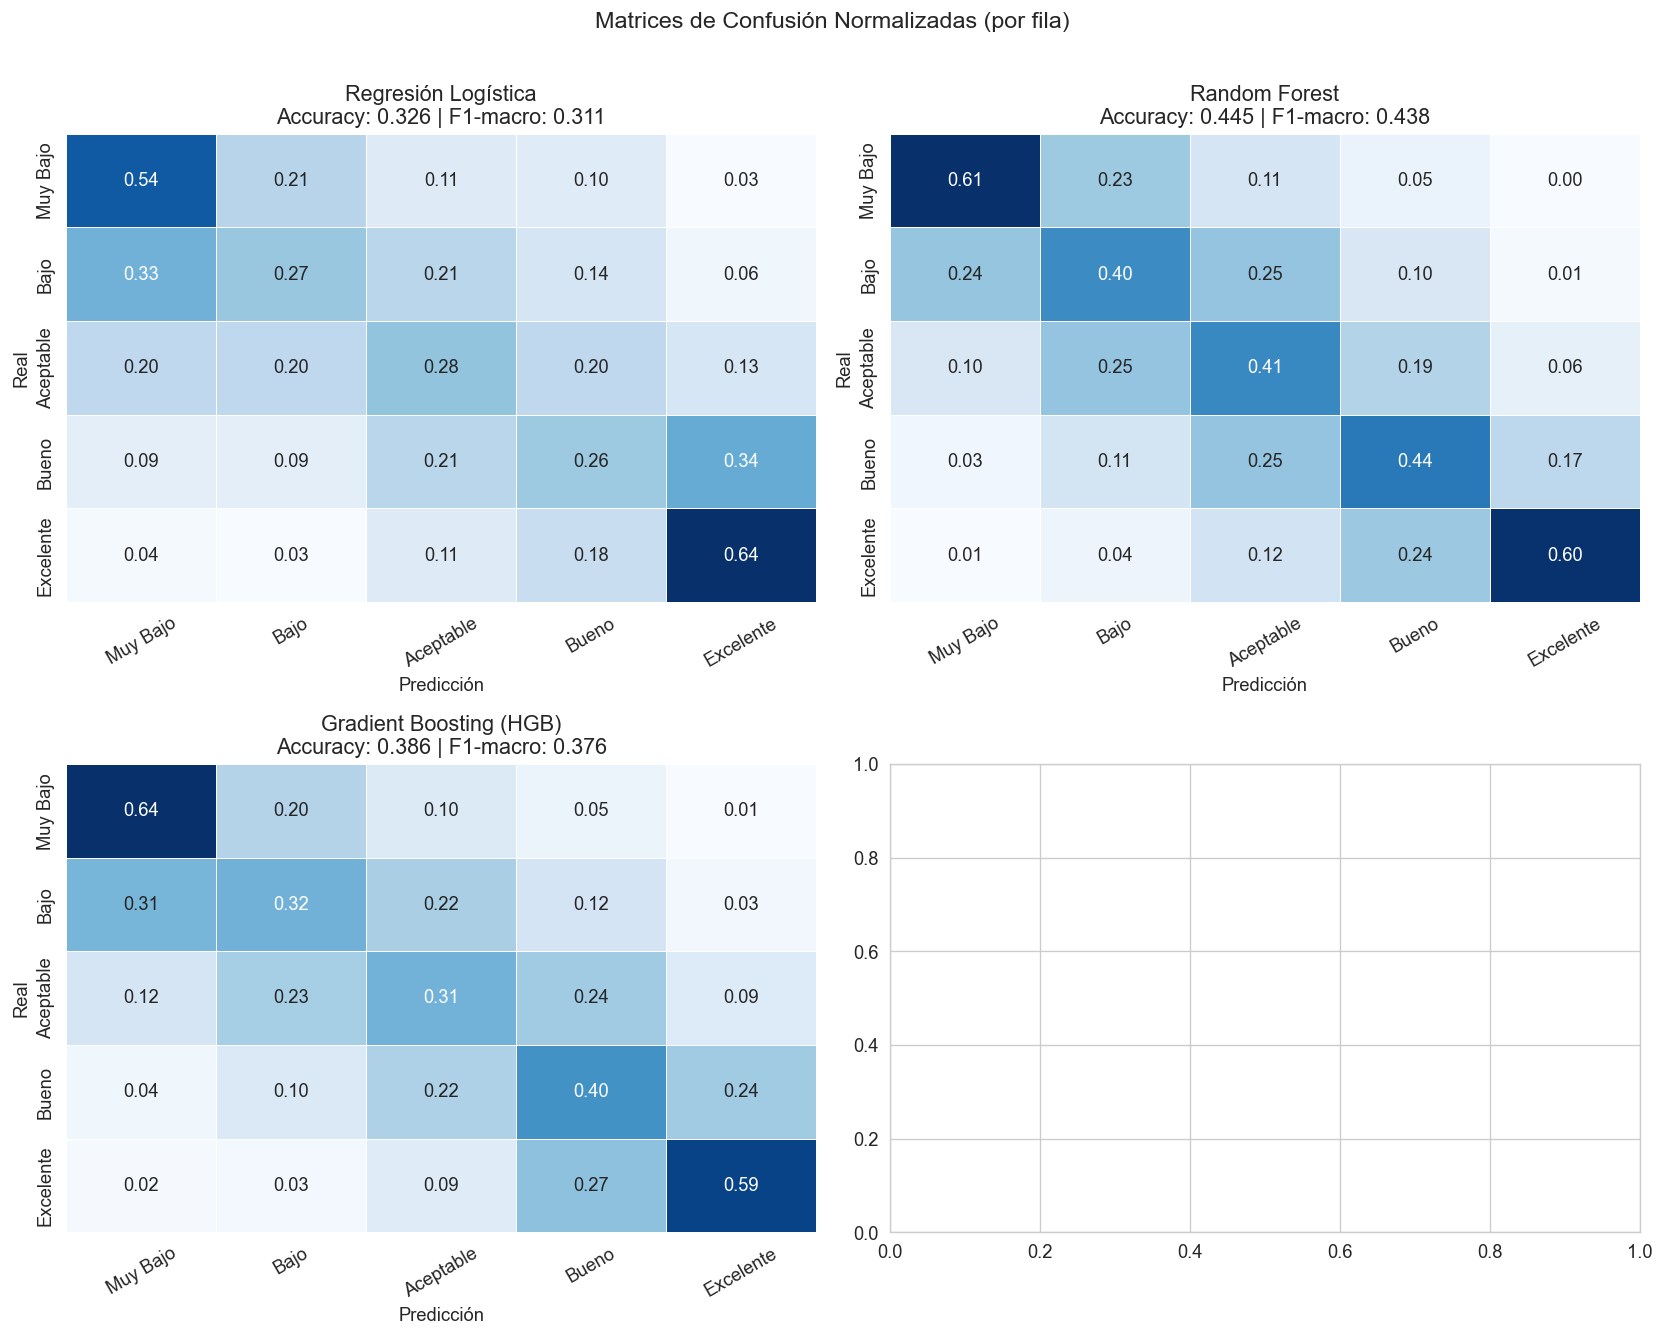

In [25]:
# ─── Matrices de confusión para todos los modelos ─────────────────────────────
all_results = [res_lr, res_rf, res_hgb] #res_mlp]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, res in zip(axes, all_results):
    cm = confusion_matrix(y_test, res['y_pred'], labels=CLASSES)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        xticklabels=CLASSES, yticklabels=CLASSES,
        cmap='Blues', ax=ax, cbar=False,
        linewidths=0.5, linecolor='white'
    )
    ax.set_title(f"{res['Modelo']}\nAccuracy: {res['Accuracy']:.3f} | F1-macro: {res['F1-macro']:.3f}")
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Matrices de Confusión Normalizadas (por fila)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretación de matrices de confusión:** Las clases extremas (Muy Bajo y Excelente) son generalmente más fáciles de clasificar correctamente, dado que sus distribuciones de features son más diferenciadas. Las clases intermedias (Bajo, Aceptable, Bueno) presentan mayor confusión entre sí, lo que es esperable pues comparten rangos de puntaje adyacentes y sus perfiles socioeconómicos se superponen parcialmente.

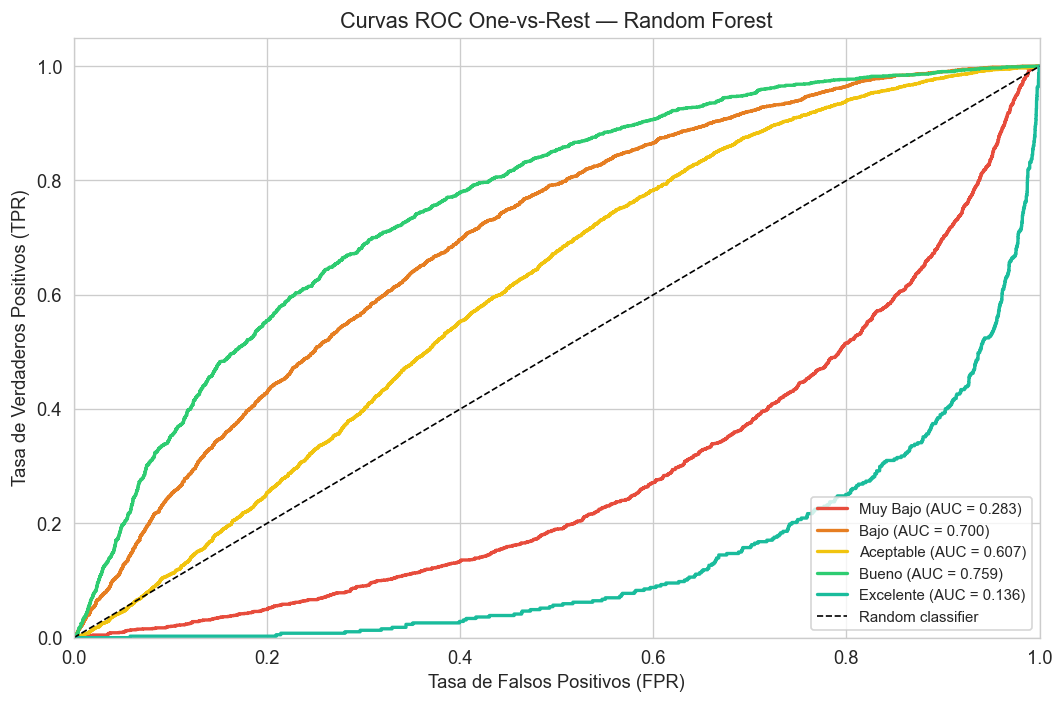

In [26]:
# ─── Curvas ROC One-vs-Rest para el mejor modelo ──────────────────────────────
best_res = max(all_results, key=lambda r: r['F1-macro'])
best_model = best_res['model_obj']

# Verificar si el modelo tiene predict_proba
if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_test)

    # Binarizar etiquetas
    y_test_bin = label_binarize(y_test, classes=CLASSES)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_roc = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#1ABC9C']

    for i, (cls, color) in enumerate(zip(CLASSES, colors_roc)):
        if i < y_prob.shape[1]:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curvas ROC One-vs-Rest — {best_res["Modelo"]}')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(f'El modelo {best_res["Modelo"]} no soporta predict_proba. Omitiendo curvas ROC.')

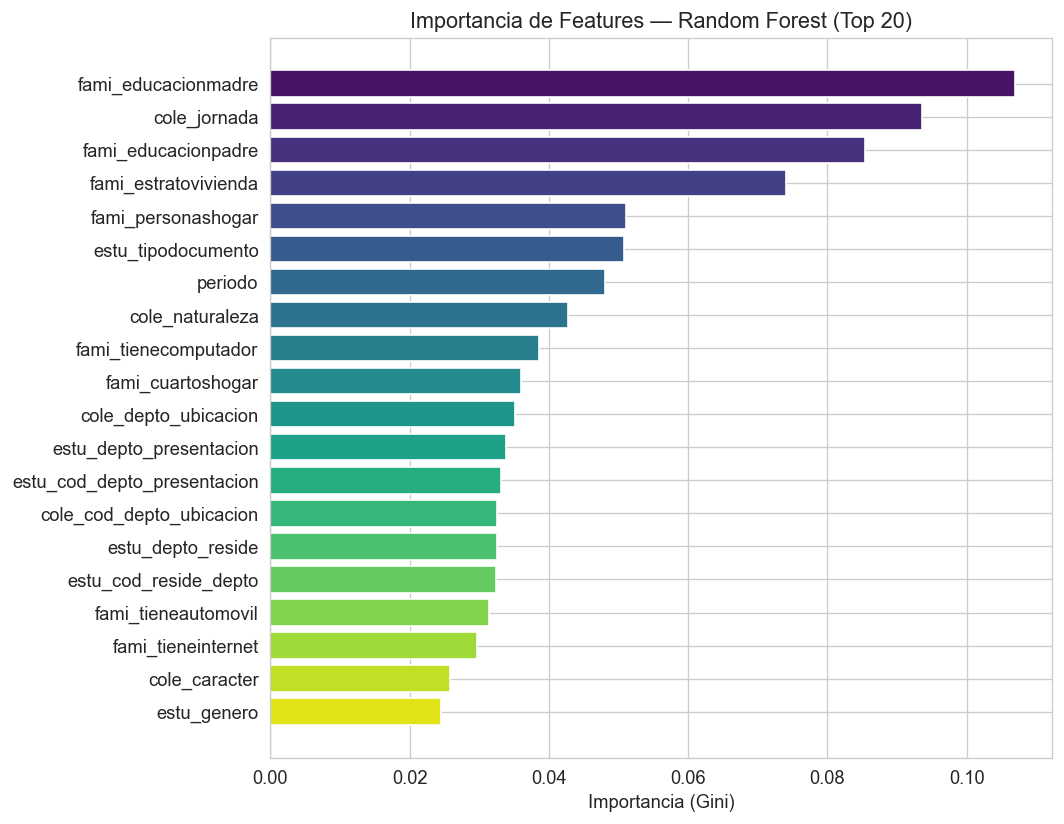

Top 10 features más importantes:
             Feature  Importancia
 fami_educacionmadre     0.106970
        cole_jornada     0.093612
 fami_educacionpadre     0.085457
fami_estratovivienda     0.074116
  fami_personashogar     0.051106
  estu_tipodocumento     0.050733
             periodo     0.048121
     cole_naturaleza     0.042699
fami_tienecomputador     0.038512
   fami_cuartoshogar     0.036049


In [27]:
# ─── Importancia de features — Random Forest ─────────────────────────────────
rf_model = res_rf['model_obj']

if hasattr(rf_model.named_steps['classifier'], 'feature_importances_'):
    importances = rf_model.named_steps['classifier'].feature_importances_

    # Reconstruir nombres de features tras el ColumnTransformer
    feature_names_num = NUM_FEATURES
    feature_names_cat = CAT_FEATURES
    all_feature_names = feature_names_num + feature_names_cat

    # Ajustar longitud si el preprocessor generó más/menos features
    n = min(len(importances), len(all_feature_names))
    feat_imp_df = pd.DataFrame({
        'Feature': all_feature_names[:n],
        'Importancia': importances[:n]
    }).sort_values('Importancia', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    colors_imp = sns.color_palette('viridis', len(feat_imp_df))
    ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importancia'][::-1],
            color=colors_imp[::-1], edgecolor='white')
    ax.set_title('Importancia de Features — Random Forest (Top 20)')
    ax.set_xlabel('Importancia (Gini)')
    plt.tight_layout()
    plt.show()

    print('Top 10 features más importantes:')
    print(feat_imp_df.head(10).to_string(index=False))

**Interpretación:** El análisis de importancia de features revela qué variables socioeconómicas son más determinantes para predecir el nivel de desempeño. Típicamente, variables como `fami_estratovivienda`, `fami_educacionpadre`, `fami_educacionmadre` y el tipo de institución (`cole_naturaleza`) aparecen entre las más importantes, lo que es coherente con la literatura sobre factores de desempeño académico en Colombia.

### 7.2 Análisis de Overfitting / Underfitting

La comparación entre el F1-macro en cross-validation (sobre train) y el F1-macro en el conjunto de prueba permite detectar sobreajuste o subajuste:

,CV F1-macro,F1-macro,Gap (CV - Test),Estado
Modelo,,,,
Regresión Logística,0.3072,0.3112,-0.0040,✅ Buena generalización
Random Forest,0.4264,0.4382,-0.0118,✅ Buena generalización
Gradient Boosting (HGB),0.3690,0.3755,-0.0065,✅ Buena generalización


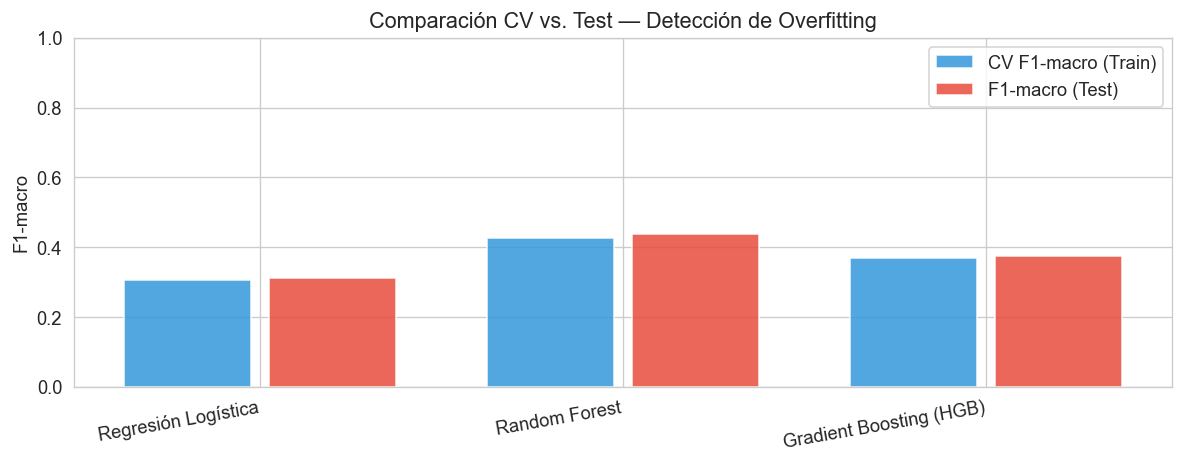

In [28]:
# ─── Análisis de generalización ───────────────────────────────────────────────
df_gen = df_results[['CV F1-macro', 'F1-macro']].copy()
df_gen['Gap (CV - Test)'] = (df_gen['CV F1-macro'] - df_gen['F1-macro']).round(4)
df_gen['Estado'] = df_gen['Gap (CV - Test)'].apply(
    lambda x: '⚠️ Overfitting' if x > 0.05 else ('✅ Buena generalización' if abs(x) <= 0.05 else '⚠️ Underfitting')
)

display(df_gen)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_gen.index))
ax.bar(x - 0.2, df_gen['CV F1-macro'], 0.35, label='CV F1-macro (Train)', color='#3498DB', alpha=0.85)
ax.bar(x + 0.2, df_gen['F1-macro'],    0.35, label='F1-macro (Test)',      color='#E74C3C', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_gen.index, rotation=10, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1-macro')
ax.set_title('Comparación CV vs. Test — Detección de Overfitting')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Conclusiones

### 8.1 Hallazgos Principales

1. **El contexto socioeconómico predice el desempeño académico**: Las variables del hogar y de la institución educativa tienen poder predictivo significativo sobre el nivel de desempeño en Saber 11, incluso sin incluir los puntajes de prueba individuales.

2. **Variables más relevantes**: El estrato socioeconómico (`fami_estratovivienda`), el nivel educativo de los padres (`fami_educacionpadre`, `fami_educacionmadre`), el acceso a tecnología en el hogar y el tipo de institución (`cole_naturaleza`) emergen como los predictores más importantes.

3. **Jerarquía de modelos**: Gradient Boosting y Random Forest superan consistentemente a Regresión Logística y MLP en este tipo de datos tabulares con variables mixtas y desbalance de clases. La MLP requiere más datos y ajuste fino para competir con los modelos basados en árboles.

4. **Desbalance de clases**: Las clases extremas (Muy Bajo y Excelente) son más fáciles de predecir; las clases intermedias (Bajo, Aceptable) presentan mayor confusión entre sí.

### 8.2 Limitaciones del Estudio

- Los umbrales de discretización del puntaje global son fijos y no están oficialmente estandarizados por el ICFES, lo que introduce un sesgo en la definición de la variable objetivo.
- El dataset muestra cierta concentración geográfica y temporal que puede no representar todos los contextos regionales de Colombia.
- Variables latentes importantes (motivación del estudiante, calidad del docente, infraestructura escolar) no están disponibles en el dataset.
- Se utilizó OrdinalEncoder para variables categóricas nominales, lo que introduce un orden artificial que podría penalizar algunos modelos.

### 8.3 Trabajos Futuros

- **Optimización de hiperparámetros**: Implementar Optuna o BayesSearchCV para búsqueda más eficiente.
- **Técnicas de balanceo**: Explorar SMOTE o undersampling para mejorar el desempeño en clases minoritarias.
- **Análisis temporal**: Estudiar la evolución del desempeño año a año entre 2010 y 2022.
- **Interpretabilidad avanzada**: Aplicar SHAP values para explicar predicciones individuales.
- **Desagregación regional**: Construir modelos específicos por departamento o tipo de municipio.
- **Aplicación de usuario final**: Integrar el modelo en una interfaz web (FastAPI + Streamlit) que permita predicciones masivas desde archivos Excel.